In [1]:
# Part 1 — Data Understanding & Exploration

import pandas as pd

In [2]:
# Read the data from the source using pandas lib

data = pd.read_csv("/content/test_zomato.csv")

In [3]:
data.head()

,Unnamed: 0,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,0,6317637,Le Petit Souffle,162.0,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,...,Botswana Pula(P),Yes,No,No,No,3.0,4.8,Dark Green,Excellent,314.0
1,1,6304287,Izakaya Kikufuji,162.0,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,...,Botswana Pula(P),Yes,No,No,No,3.0,4.5,Dark Green,Excellent,591.0
2,2,6300002,Heat - Edsa Shangri-La,162.0,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,...,Botswana Pula(P),Yes,No,No,No,4.0,4.4,Green,Very Good,270.0
3,3,6318506,Ooma,162.0,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,...,Botswana Pula(P),No,No,No,No,4.0,4.9,Dark Green,Excellent,365.0
4,4,6314302,Sambo Kojin,162.0,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.58445,...,Botswana Pula(P),Yes,No,No,No,4.0,4.8,Dark Green,Excellent,229.0


In [4]:
# Print the shape of the data

print(data.shape)

(9552, 22)


In [5]:
# Print all columns

print(data.columns)

Index(['Unnamed: 0', 'Restaurant ID', 'Restaurant Name', 'Country Code',
       'City', 'Address', 'Locality', 'Locality Verbose', 'Longitude',
       'Latitude', 'Cuisines', 'Average Cost for two', 'Currency',
       'Has Table booking', 'Has Online delivery', 'Is delivering now',
       'Switch to order menu', 'Price range', 'Aggregate rating',
       'Rating color', 'Rating text', 'Votes'],
      dtype='object')


In [6]:
# Print the data type of each columns

print(data.dtypes)

Unnamed: 0               object
Restaurant ID            object
Restaurant Name          object
Country Code            float64
City                     object
Address                  object
Locality                 object
Locality Verbose         object
Longitude                object
Latitude                 object
Cuisines                 object
Average Cost for two     object
Currency                 object
Has Table booking        object
Has Online delivery      object
Is delivering now        object
Switch to order menu     object
Price range             float64
Aggregate rating        float64
Rating color             object
Rating text              object
Votes                   float64
dtype: object


In [7]:
# Print Count of null values in each column in the data

print(data.isna().sum())

Unnamed: 0               0
Restaurant ID            0
Restaurant Name          0
Country Code             0
City                     0
Address                  0
Locality                 1
Locality Verbose         1
Longitude                1
Latitude                 1
Cuisines                10
Average Cost for two     1
Currency                 1
Has Table booking        1
Has Online delivery      1
Is delivering now        1
Switch to order menu     1
Price range              2
Aggregate rating         2
Rating color             2
Rating text              2
Votes                    2
dtype: int64


In [8]:
# Identify duplicate records (if any)

duplicated_records = data.duplicated().sum()
print(f"Total duplicate records: {duplicated_records}")

Total duplicate records: 0


In [9]:
# Displays the rows that are duplicated (if any)

duplicated_rows = data[data.duplicated()]
print(duplicated_rows)

Empty DataFrame
Columns: [Unnamed: 0, Restaurant ID, Restaurant Name, Country Code, City, Address, Locality, Locality Verbose, Longitude, Latitude, Cuisines, Average Cost for two, Currency, Has Table booking, Has Online delivery, Is delivering now, Switch to order menu, Price range, Aggregate rating, Rating color, Rating text, Votes]
Index: []

[0 rows x 22 columns]


In [10]:
# Checking the current data type of average cost for two column

avg_cost_for_two_dtype = data['Average Cost for two'].dtypes
print(avg_cost_for_two_dtype)

object


In [11]:
# Displaying the values inside the column

print(data['Average Cost for two'])

0       1100
1       1200
2       4000
3       1500
4       1500
        ... 
9547      80
9548     105
9549     170
9550     120
9551      55
Name: Average Cost for two, Length: 9552, dtype: object


In [12]:
# Checking if all the value inside the column is numberic or not and printing only the rows which have non numberic values

is_numeric = data['Average Cost for two'].astype(str).str.isnumeric()
print(data[~is_numeric][['Restaurant Name', 'Average Cost for two']])

                                Restaurant Name Average Cost for two
472                                  Super Loco                  NaN
473  Robertson Quay, Singapore River, Singapore                   No


In [13]:
# Converting object data type into numberic data type

data['Average Cost for two'] = pd.to_numeric(data['Average Cost for two'], errors="coerce")
print(data['Average Cost for two'].dtypes)

float64


In [14]:
# Statistical analysis

data.describe()

,Country Code,Average Cost for two,Price range,Aggregate rating,Votes
count,9552.000000,9550.000000,9550.000000,9550.000000,9550.000000
mean,18.374564,1199.326387,1.804607,2.666314,156.923037
std,56.754313,16122.023220,0.905378,1.516447,430.189709
min,1.000000,0.000000,1.000000,0.000000,0.000000
25%,1.000000,250.000000,1.000000,2.500000,5.000000
50%,1.000000,400.000000,2.000000,3.200000,31.000000
75%,1.000000,700.000000,2.000000,3.700000,131.000000
max,216.000000,800000.000000,4.000000,4.900000,10934.000000


In [15]:
# mean, median and mode of the col 'Average cost for two'

print(data['Average Cost for two'].mean())
print(data['Average Cost for two'].median())
print(data['Average Cost for two'].mode())

1199.326387434555
400.0
0    500.0
Name: Average Cost for two, dtype: float64


In [16]:
# How many unique cities are present in the dataset?

no_of_unique_cities = data['City'].nunique()
print(f"No.of Unique cities: {no_of_unique_cities}")

No.of Unique cities: 142


In [17]:
# Which city has the highest number of restaurants?

city_with_highest_no_of_restaurents = data['City'].value_counts().idxmax()
print(f"City with the highest number of restaurents: {city_with_highest_no_of_restaurents}")

City with the highest number of restaurents: New Delhi


In [18]:
# Which cuisine appears most frequently?

most_freequent_cuisine = data['Cuisines'].value_counts().idxmax()
print(f"Which cuisine appears most freequently: {most_freequent_cuisine}")

Which cuisine appears most freequently: North Indian


In [19]:
# Part 2 - Data Analysis

In [24]:
# Find the average restaurant rating

# Checking the type of the col 'Aggregate rating'
print(data['Aggregate rating'].dtype)

# taking the avg of col 'Aggregate rating'
avg_rating_of_restaurents = data['Aggregate rating'].mean()
print(f"Average rating of restaurents is: {avg_rating_of_restaurents:.2f}")

float64
Average rating of redstaurents is: 2.67


In [38]:
# Identify the restaurant with the highest number of votes

highest_vote = data['Votes'].idxmax()

restaurant_with_highest_vote = data.loc[highest_vote, 'Restaurant Name']
restaurant_with_highest_vote_value = data.loc[highest_vote, 'Votes']

print(f"Restaurant with highest vote is {restaurant_with_highest_vote} with a vote count of {int(restaurant_with_highest_vote_value)}")

Restaurant with highest vote is Toit with a vote count of 10934


In [39]:
# Find the average cost for two across all restaurants

overall_avg_cost = data['Average Cost for two'].mean()

print(f"The average cost for two across all restaurants is: {overall_avg_cost:.2f}")

The average cost for two across all restaurants is: 1199.33


In [57]:
# Compare the average ratings of restaurants that:
# a. Have Online Delivery
# b. Do Not Have Online Delivery

delivery_stats = data.groupby('Has Online delivery')['Aggregate rating'].mean()

print(delivery_stats)
print()

# Cleaned up version

filtered_stats = delivery_stats.loc[['Yes', 'No']]
print(filtered_stats)

Has Online delivery
No        2.465192
Orange         NaN
Yes       3.248837
Name: Aggregate rating, dtype: float64

Has Online delivery
Yes    3.248837
No     2.465192
Name: Aggregate rating, dtype: float64


In [58]:
# Compare the average ratings of restaurants that:
# a. Have Table Booking
# b. Do Not Have Table Booking

booking_stats = data.groupby('Has Table booking')['Aggregate rating'].mean()

print(booking_stats)
print()

# Cleaned up version

filtered_booking_stats = booking_stats.loc[['Yes', 'No']]
print(filtered_booking_stats)

Has Table booking
3.2         NaN
No     2.559283
Yes    3.441969
Name: Aggregate rating, dtype: float64

Has Table booking
Yes    3.441969
No     2.559283
Name: Aggregate rating, dtype: float64


In [59]:
# Identify the top 10 cities with the highest number of restaurants

top_10_cities = data['City'].value_counts().head(10)

print("Top 10 Cities with the highest number of restaurants are:")
print(top_10_cities)

Top 10 Cities with the highest number of restaurants:
City
New Delhi       5473
Gurgaon         1118
Noida           1080
Faridabad        251
Ghaziabad         25
Ahmedabad         21
Bhubaneshwar      21
Lucknow           21
Guwahati          21
Amritsar          21
Name: count, dtype: int64


In [ ]:
# Part 3 — Data Visualization

In [61]:
# importing required libs for the data visualization

import matplotlib.pyplot as plt
import seaborn as sb

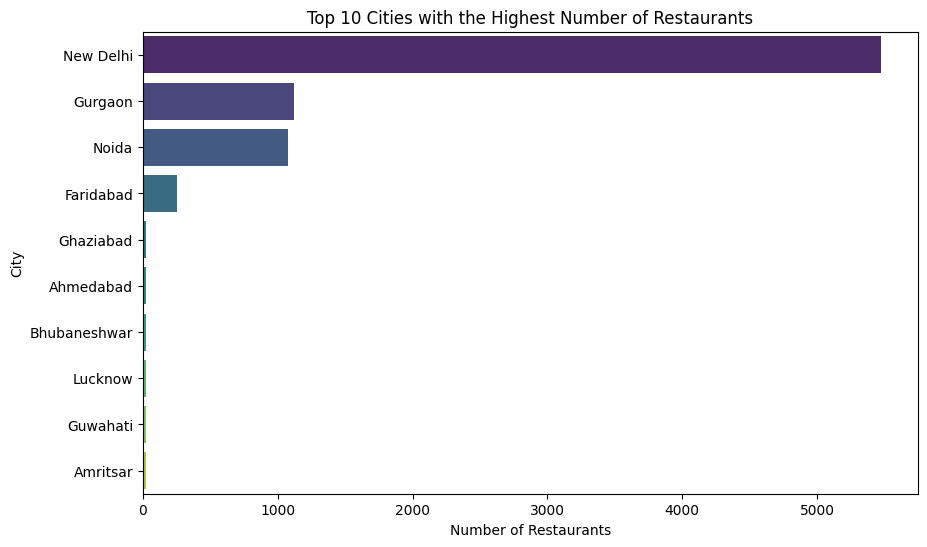

In [66]:
# 1. Bar Chart: Top 10 cities with the highest number of restaurants

plt.figure(figsize=(10, 6))
top_10_cities = data['City'].value_counts().head(10)
sb.barplot(x=top_10_cities.values, y=top_10_cities.index, hue=top_10_cities.index, palette='viridis', legend=False)
plt.title('Top 10 Cities with the Highest Number of Restaurants')
plt.xlabel('Number of Restaurants')
plt.ylabel('City')
plt.show()

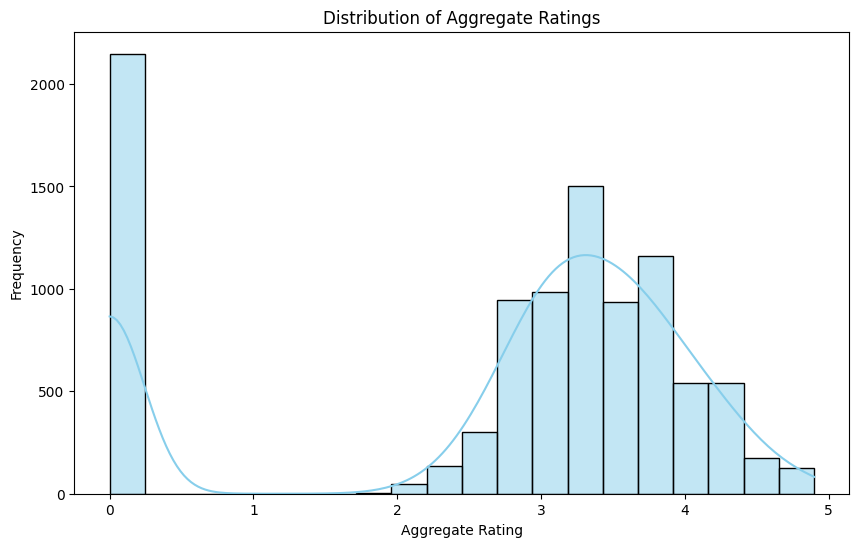

In [64]:
# 2. Histogram: Distribution of Aggregate Ratings

plt.figure(figsize=(10, 6))
sb.histplot(data['Aggregate rating'], bins=20, kde=True, color='skyblue')
plt.title('Distribution of Aggregate Ratings')
plt.xlabel('Aggregate Rating')
plt.ylabel('Frequency')
plt.show()

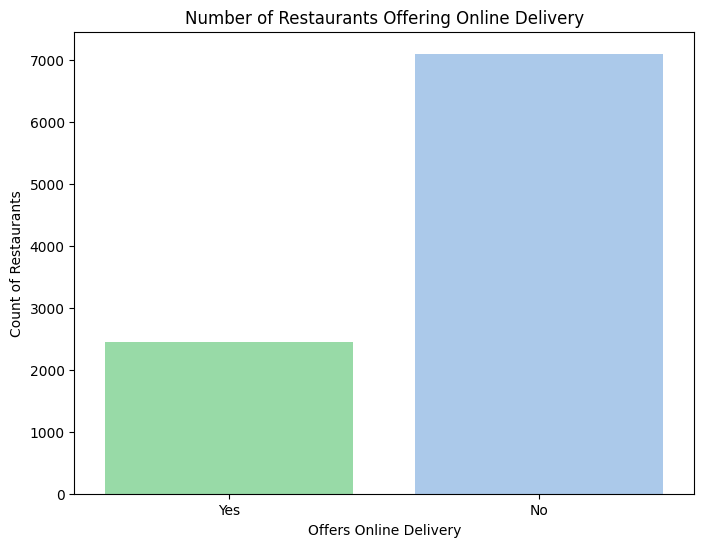

In [67]:
# 3. Bar Chart: Number of restaurants offering Online Delivery (Yes/No)

plt.figure(figsize=(8, 6))
sb.countplot(x='Has Online delivery', data=data, hue='Has Online delivery', palette='pastel', order=['Yes', 'No'], legend=False)
plt.title('Number of Restaurants Offering Online Delivery')
plt.xlabel('Offers Online Delivery')
plt.ylabel('Count of Restaurants')
plt.show()

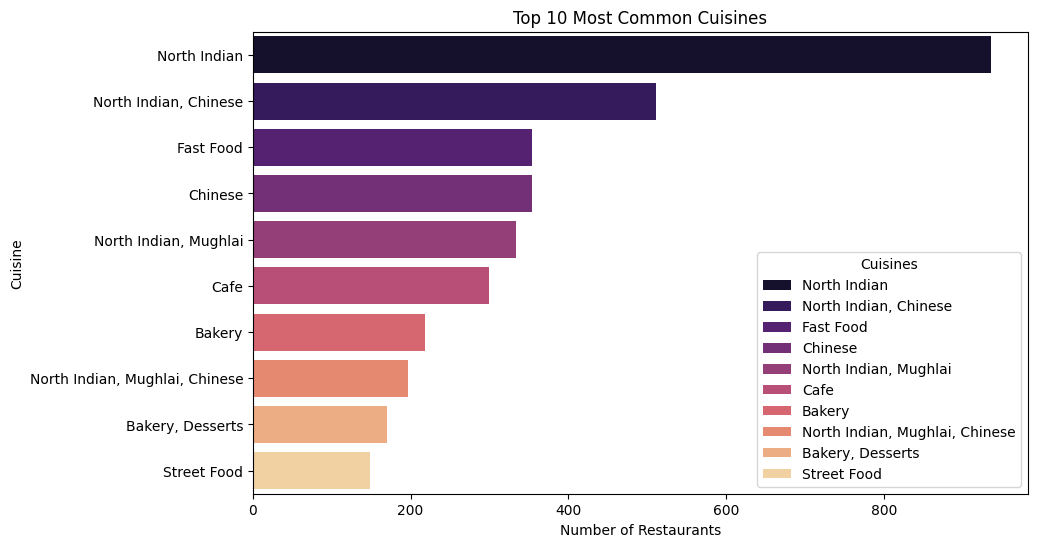

In [70]:
# 4. Bar Chart: Top 10 most common cuisines

plt.figure(figsize=(10, 6))
top_10_cuisines = data['Cuisines'].value_counts().head(10)
sb.barplot(x=top_10_cuisines.values, y=top_10_cuisines.index, hue=top_10_cuisines.index, palette='magma', legend=True)
plt.title('Top 10 Most Common Cuisines')
plt.xlabel('Number of Restaurants')
plt.ylabel('Cuisine')
plt.show()

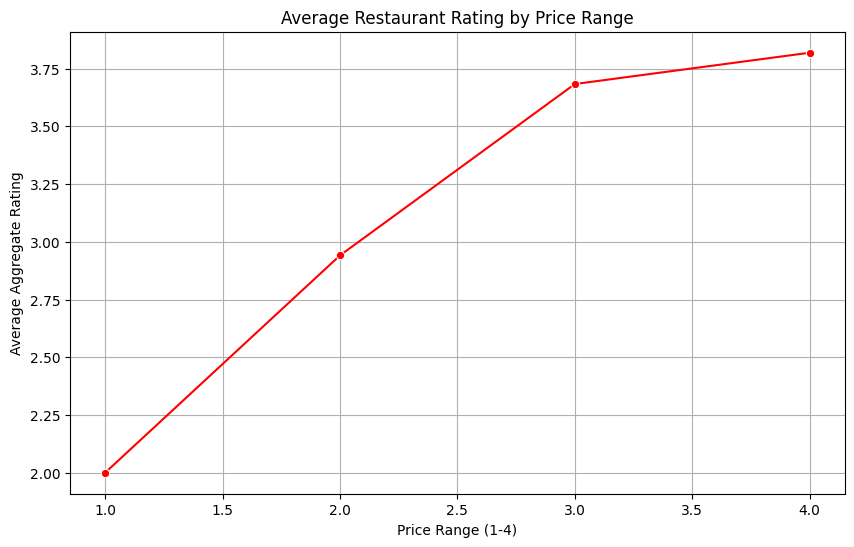

In [69]:
# 5. Line Chart: Average restaurant rating by Price Range

plt.figure(figsize=(10, 6))
avg_rating_price = data.groupby('Price range')['Aggregate rating'].mean().reset_index()
sb.lineplot(x='Price range', y='Aggregate rating', data=avg_rating_price, marker='o', color='red')
plt.title('Average Restaurant Rating by Price Range')
plt.xlabel('Price Range (1-4)')
plt.ylabel('Average Aggregate Rating')
plt.grid(True)
plt.show()